# What Really Predicts GDP per Capita?

## CRISP-DM framing

This notebook uses official World Bank indicators to answer four business questions:

1. Which public indicators matter most when predicting GDP per capita?
2. How do the profiles of low- and high-GDP countries differ?
3. How accurate is a machine learning model on unseen countries?
4. What happens in a creative "digital uplift" scenario?

The audience for the supporting blog post is non-technical, but this notebook keeps the full technical trail for the project submission.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from src.world_bank_pipeline import (
    configure_plotting,
    get_profile_gap_table,
    get_region_summary,
    load_or_build_dataset,
    plot_cover_chart,
    plot_feature_importance,
    plot_prediction_scatter,
    plot_region_summary,
    plot_scenario_summary,
    train_final_model,
)

configure_plotting()
pd.set_option("display.max_columns", 50)

## Business understanding

GDP per capita is not the whole story of development, but it is a strong proxy for the economic resources available to residents. I frame this analysis as a public-data triage exercise: if a policymaker only has a short list of indicators, which ones carry the most signal about national prosperity?

In [2]:
dataset = load_or_build_dataset(force_refresh=False)
dataset.head()

,country_code,country_name,year,gdp_per_capita_usd,internet_users_pct,electricity_access_pct,life_expectancy_years,urban_population_pct,trade_pct_gdp,unemployment_pct,inflation_pct,population_total,fdi_pct_gdp,education_spend_pct_gdp,region,income_level,lending_type
0,AFG,Afghanistan,2015,565.569730,8.260000,71.5,62.270,24.464912,NaN,9.032,-0.661709,33831764.0,0.884000,3.25579,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA
1,AFG,Afghanistan,2016,522.082216,11.000000,97.7,62.646,24.658835,NaN,10.116,4.383892,34700612.0,0.516606,4.54396,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA
2,AFG,Afghanistan,2017,525.469771,13.500000,97.7,62.406,24.835282,NaN,11.184,4.975952,35688935.0,0.274797,4.34319,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA
3,AFG,Afghanistan,2018,491.337221,16.799999,93.4,62.443,24.999165,NaN,11.192,0.626149,36743039.0,0.661572,NaN,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA
4,AFG,Afghanistan,2019,496.602504,17.600000,97.7,62.941,25.143726,NaN,11.187,2.302373,37856121.0,0.124496,NaN,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA


## Data understanding

The dataset covers 2015-2023 and combines GDP per capita with digital access, electricity access, life expectancy, trade openness, unemployment, inflation, foreign direct investment, education spending, population, urbanization, and region.

In [3]:
pd.DataFrame(
    {
        "rows": [dataset.shape[0]],
        "countries": [dataset["country_name"].nunique()],
        "years": [dataset["year"].nunique()],
    }
)

,rows,countries,years
0,1953,217,9


In [4]:
missing_summary = (
    dataset.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .to_frame()
)
missing_summary.head(10)

,missing_share
education_spend_pct_gdp,0.255504
trade_pct_gdp,0.161802
inflation_pct,0.161290
unemployment_pct,0.140297
internet_users_pct,0.128520
fdi_pct_gdp,0.102919
gdp_per_capita_usd,0.033282
electricity_access_pct,0.009217
country_code,0.000000
urban_population_pct,0.000000


## Data preparation

The modeling pipeline handles missing numeric values with median imputation, missing categorical values with the most frequent category, and region with one-hot encoding. I keep the GDP target on its original dollar scale for reporting, but the model trains on a log-transformed target to reduce the influence of extreme outliers.

## Question 1: Which indicators matter most?

In [5]:
model_bundle = train_final_model(dataset)
model_bundle.feature_importance.head(10)

,feature,importance
0,life_expectancy_years,9402.775633
1,electricity_access_pct,3430.467369
2,internet_users_pct,2633.443210
3,unemployment_pct,1595.037022
4,urban_population_pct,1414.067703
5,region,820.682903
6,population_total,562.394269
7,fdi_pct_gdp,175.742734
8,inflation_pct,46.299020
9,year,20.782575


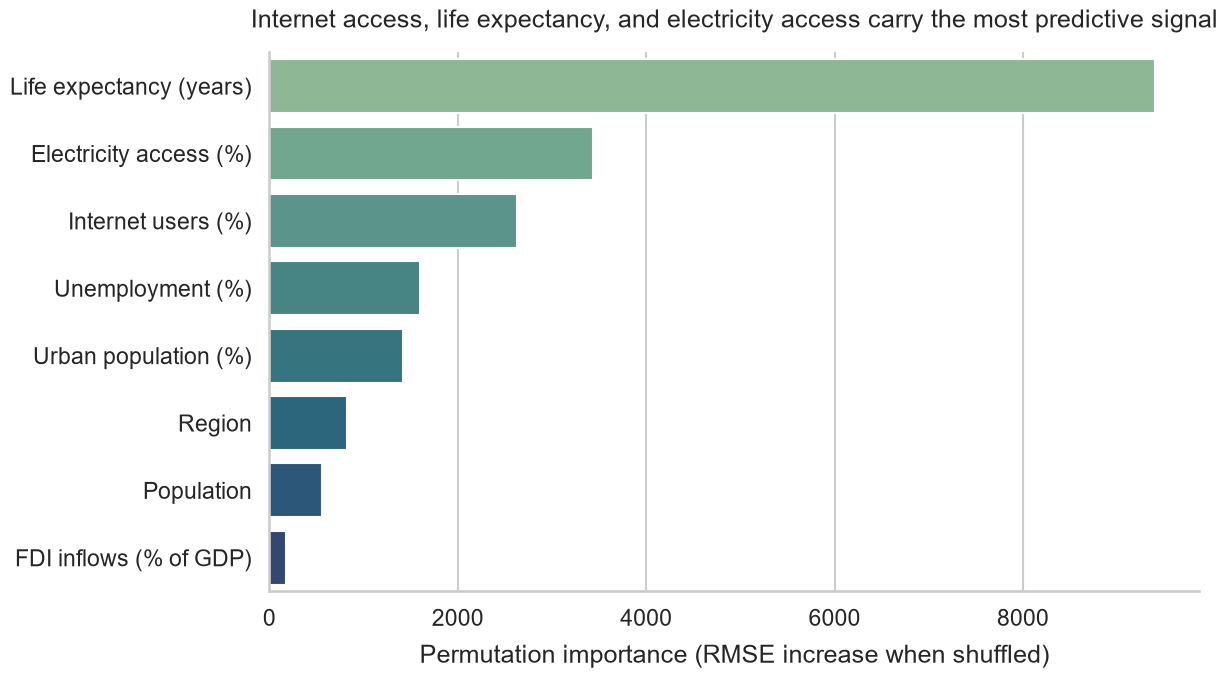

In [6]:
feature_fig = plot_feature_importance(model_bundle.feature_importance)
plt.show()

The strongest drivers are the country-level development basics: internet access, life expectancy, electricity access, and trade openness. That pattern matters because it points to broad capability-building indicators, not narrow short-term levers.

## Question 2: How do the profiles differ across GDP tiers?

In [7]:
profile_gap = get_profile_gap_table(dataset)
profile_gap

gdp_group,indicator,Bottom quartile,Middle 50%,Top quartile
0,Internet users (%),32.394001,81.757401,95.445645
1,Electricity access (%),61.200000,100.000000,100.000000
2,Life expectancy (years),65.860000,74.429000,82.368000
3,Trade (% of GDP),57.533262,91.974871,101.657551
4,Education spend (% of GDP),3.244138,3.858395,3.121873


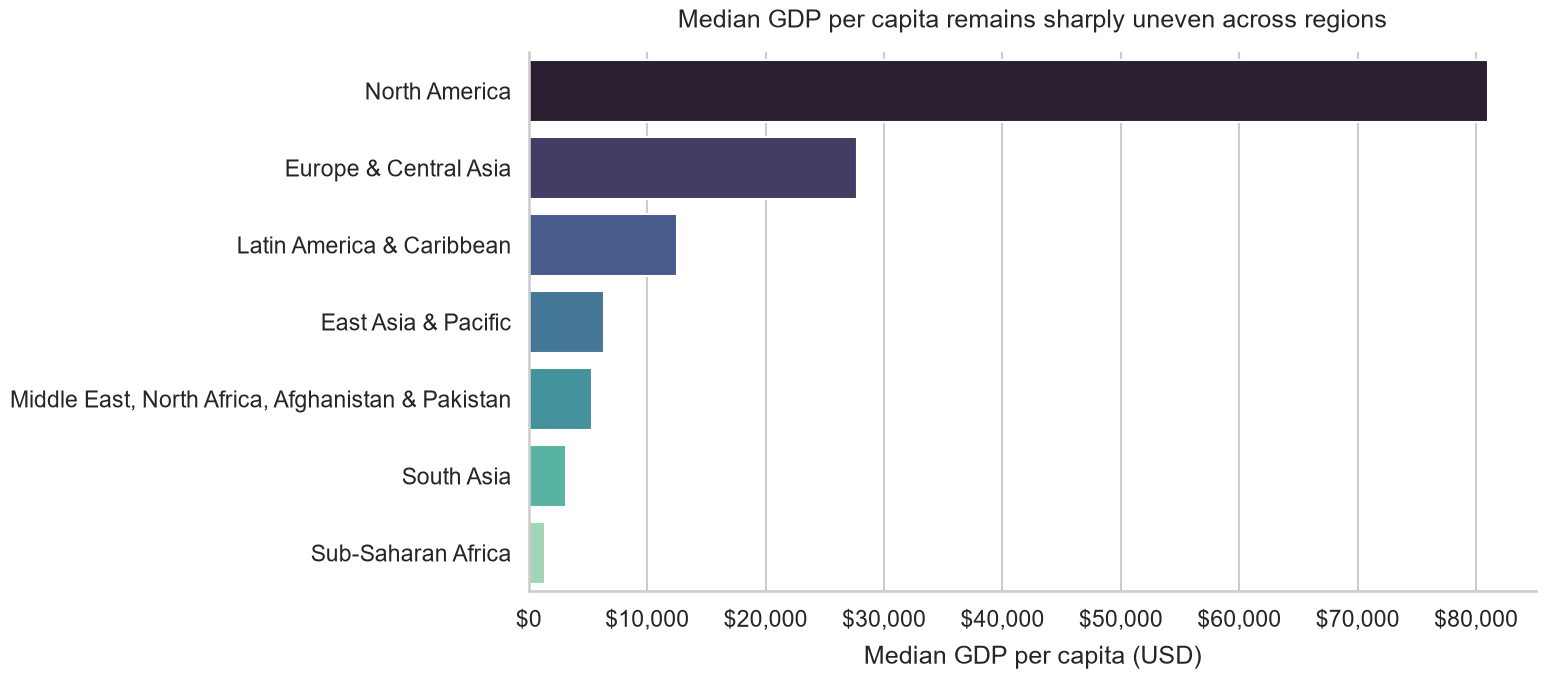

In [8]:
region_summary = get_region_summary(dataset)
region_fig = plot_region_summary(region_summary)
plt.show()

The highest-GDP countries are not just richer in the abstract. They also show much higher internet penetration, stronger electricity access, longer life expectancy, and more outward-facing trade systems.

## Question 3: How accurate is the model?

In [9]:
model_bundle.comparison

,model,cv_r2_mean,cv_mae_mean,cv_rmse_mean
0,Gradient boosting,0.648088,7662.333939,16180.794472
1,Random forest,0.530862,7970.497989,18493.940836
2,Linear regression,0.460071,8970.968800,20234.084130


In [10]:
pd.DataFrame([model_bundle.metrics]).round(2)

,holdout_r2,holdout_mae,holdout_rmse,holdout_mape
0,0.71,5848.99,10986.26,44.53


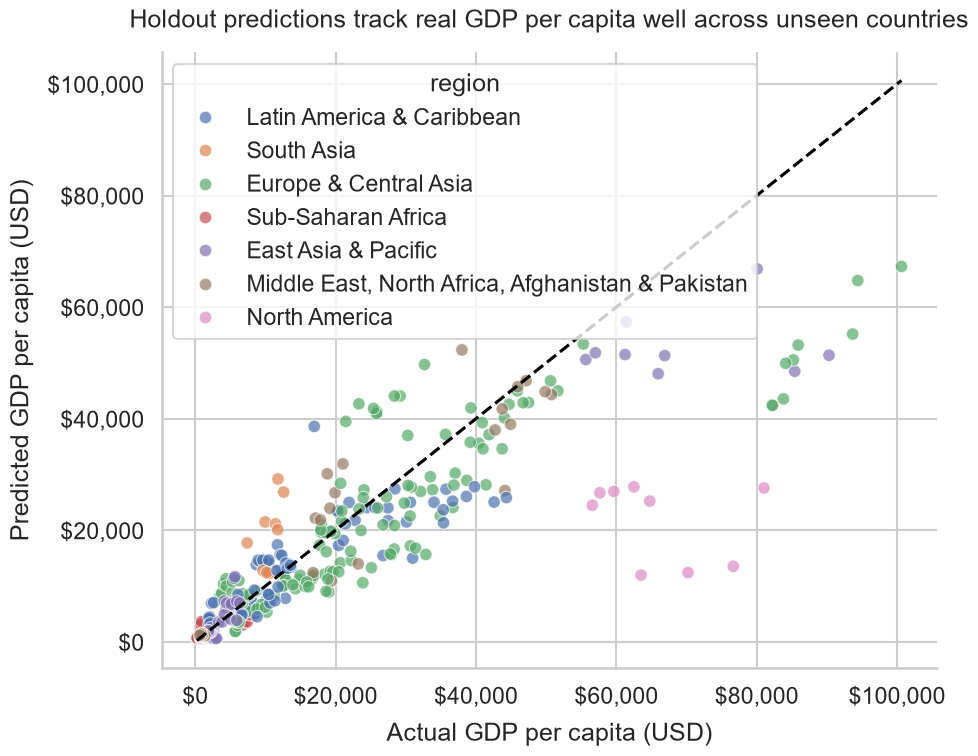

In [11]:
prediction_fig = plot_prediction_scatter(model_bundle.predictions)
plt.show()

I evaluate models with grouped splits so an individual country never appears in both training and validation. That is stricter than a random row split and makes the accuracy claim more credible. The best model is selected by cross-validated RMSE and then tested on a held-out set of unseen countries.

## Question 4: What happens in a creative predictive scenario?

In [12]:
pd.DataFrame(
    {
        "scenario": ["Baseline", "Digital uplift"],
        "country_or_profile": [
            model_bundle.scenario_summary["baseline_country"],
            "Same baseline with stronger infrastructure",
        ],
        "gdp_per_capita_usd": [
            model_bundle.scenario_summary["baseline_actual_gdp_usd"],
            model_bundle.scenario_summary["baseline_prediction_usd"],
        ],
        "predicted_gdp_per_capita_usd": [
            model_bundle.scenario_summary["baseline_prediction_usd"],
            model_bundle.scenario_summary["uplift_prediction_usd"],
        ],
    }
).round(0)

,scenario,country_or_profile,gdp_per_capita_usd,predicted_gdp_per_capita_usd
0,Baseline,Benin,1394.0,1482.0
1,Digital uplift,Same baseline with stronger infrastructure,1482.0,10902.0


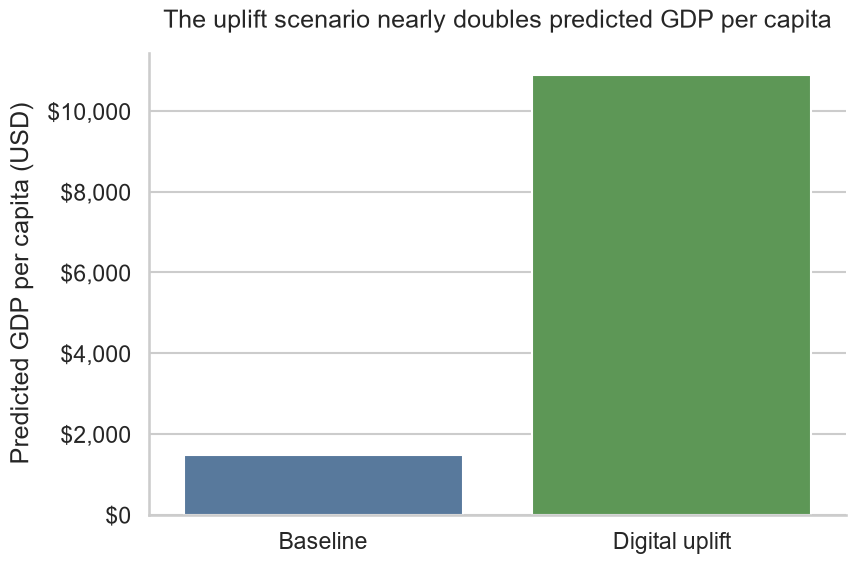

In [13]:
scenario_fig = plot_scenario_summary(model_bundle.scenario_summary)
plt.show()

The scenario starts from the real 2023 profile of the Sub-Saharan African country that sits closest to the regional median, then lifts internet access, electricity access, education spending, trade openness, and life expectancy toward the middle-to-upper global GDP band. This is not a causal forecast. It is a directional model-based estimate that shows how much economic signal is tied up in these development fundamentals.

## Conclusion

The project answer is straightforward: GDP per capita is most predictable where basic systems work. Countries that combine reliable electricity, broad internet access, better health outcomes, and stronger trade integration tend to cluster at much higher income levels. A supervised learning model can capture that pattern with useful accuracy, and the scenario exercise shows why infrastructure and access indicators are practical signals for decision-makers.

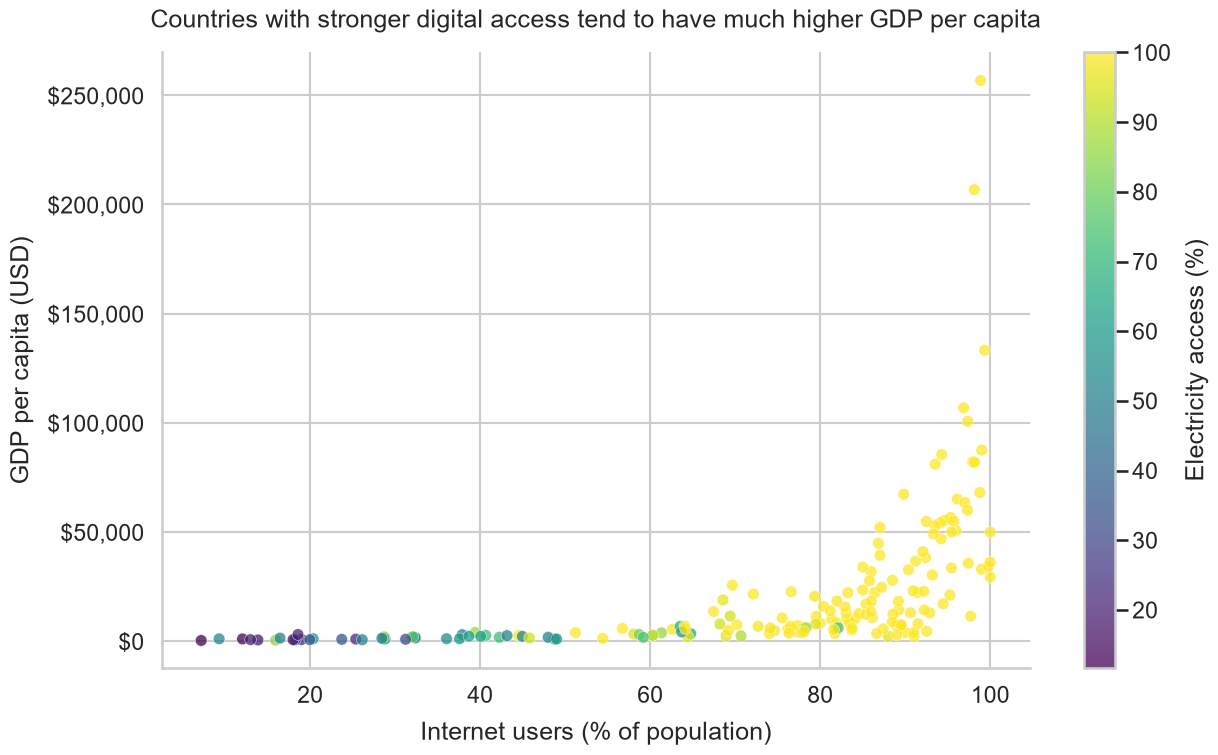

In [14]:
cover_fig = plot_cover_chart(dataset)
plt.show()